# 🔬 LABORATORIO — SEMANA 1
## Análisis de Datos con Python + Identificación de Tipos de Datos
### Big Data (DD283) | Universidad Autónoma del Perú

---

* **Nombre(s):** Alexis Velarde  
* **Grupo:** Grupo 2  
* **Duración estimada:** 90 minutos  
* **Modalidad:** Individual (en casa, en tu laptop)  
* **Entrega:** Subir notebook `.ipynb` a GitHub Classroom antes de la Semana 2  

---

## 🎯 OBJETIVO DEL LABORATORIO

Al completar este laboratorio, serás capaz de:

* [x] **Cargar y explorar** diferentes tipos de datos utilizando Python.
* [x] **Identificar** con precisión las características de Big Data en entornos y conjuntos de datos reales.
* [x] **Calcular** métricas críticas de volumen, veracidad y velocidad de procesamiento de datos.
* [x] **Desarrollar y estructurar** tu primer notebook profesional de análisis de datos.


## 🛠️ PARTE 1: CONFIGURACIÓN DEL ENTORNO (10 minutos)

### Paso 1.1: Instalar e importar librerías



In [2]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

# Verificar versiones
print(f"Pandas version: {pd.__version__}")
print(f"Python version: {os.sys.version}")
print("¡Entorno listo!")

Pandas version: 3.0.3
Python version: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
¡Entorno listo!


## 📊 PARTE 2: DATOS ESTRUCTURADOS (20 minutos)

### Paso 2.1: Cargar datos reales de una empresa peruana

En este paso, inicializaremos un dataset transaccional sintético basado en las métricas y comportamientos de consumo del mercado retail en el Perú (Supermercados / Tiendas por departamento).

In [3]:
# Crear un dataset simulado de transacciones de una empresa peruana
# (basado en patrones reales del mercado peruano)

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Crear dataset de transacciones
np.random.seed(42)
n_transacciones = 10000

fechas = pd.date_range(start='2024-01-01', end='2024-12-31', periods=n_transacciones)
departamentos = ['Lima', 'Arequipa', 'Cusco', 'Trujillo', 'Piura', 'Chiclayo', 'Iquitos', 'Huancayo']
categorias = ['Alimentos', 'Electrodomésticos', 'Ropa', 'Farmacia', 'Tecnología', 'Deportes']

transacciones = pd.DataFrame({
    'id_transaccion': range(1, n_transacciones + 1),
    'fecha': fechas,
    'cliente_id': np.random.randint(1000, 9999, n_transacciones),
    'departamento': np.random.choice(departamentos, n_transacciones, 
                                     p=[0.45, 0.12, 0.10, 0.09, 0.08, 0.07, 0.05, 0.04]),
    'categoria': np.random.choice(categorias, n_transacciones),
    'monto_soles': np.round(np.random.exponential(150, n_transacciones) + 20, 2),
    'metodo_pago': np.random.choice(['Yape', 'Plin', 'Tarjeta', 'Efectivo', 'BIM'], 
                                     n_transacciones, p=[0.30, 0.20, 0.25, 0.20, 0.05]),
    'es_fraude': np.random.choice([0, 1], n_transacciones, p=[0.98, 0.02])
})

print(f"Dataset creado con {len(transacciones):,} registros")
print(f"Columnas: {list(transacciones.columns)}")
print(f"\nPrimeras 5 filas:")
transacciones.head()

Dataset creado con 10,000 registros
Columnas: ['id_transaccion', 'fecha', 'cliente_id', 'departamento', 'categoria', 'monto_soles', 'metodo_pago', 'es_fraude']

Primeras 5 filas:


,id_transaccion,fecha,cliente_id,departamento,categoria,monto_soles,metodo_pago,es_fraude
0,1,2024-01-01 00:00:00.000000,8270,Piura,Tecnología,79.56,Plin,0
1,2,2024-01-01 00:52:33.915391,1860,Lima,Deportes,83.21,BIM,0
2,3,2024-01-01 01:45:07.830783,6390,Arequipa,Deportes,171.93,Plin,0
3,4,2024-01-01 02:37:41.746174,6191,Lima,Farmacia,61.13,BIM,0
4,5,2024-01-01 03:30:15.661566,6734,Trujillo,Farmacia,58.13,Plin,0


In [5]:
# Exploración básica
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"\nTamaño del dataset: {transacciones.shape}")
print(f"Filas: {transacciones.shape[0]:,}")
print(f"Columnas: {transacciones.shape[1]}")

print("\n=== TIPOS DE DATOS POR COLUMNA ===")
print(transacciones.dtypes)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(transacciones.describe())

print("\n=== VALORES NULOS ===")
print(transacciones.isnull().sum())

=== INFORMACIÓN GENERAL DEL DATASET ===

Tamaño del dataset: (10000, 8)
Filas: 10,000
Columnas: 8

=== TIPOS DE DATOS POR COLUMNA ===
id_transaccion             int64
fecha             datetime64[us]
cliente_id                 int32
departamento                 str
categoria                    str
monto_soles              float64
metodo_pago                  str
es_fraude                  int64
dtype: object

=== ESTADÍSTICAS DESCRIPTIVAS ===
       id_transaccion                       fecha    cliente_id   monto_soles  \
count     10000.00000                       10000  10000.000000  10000.000000   
mean       5000.50000  2024-07-01 11:59:59.999999   5462.898000    169.863176   
min           1.00000         2024-01-01 00:00:00   1001.000000     20.000000   
25%        2500.75000  2024-04-01 05:59:59.999999   3217.000000     64.032500   
50%        5000.50000  2024-07-01 11:59:59.999999   5477.000000    125.255000   
75%        7500.25000  2024-09-30 17:59:59.999999   7698.000000    

In [6]:
# Calcular las 5 V's para este dataset

# VOLUMEN
tamaño_bytes = transacciones.memory_usage(deep=True).sum()
print("=== ANÁLISIS DE VOLUMEN ===")
print(f"Registros: {len(transacciones):,}")
print(f"Tamaño en memoria: {tamaño_bytes / 1024:.1f} KB")
print(f"Si escalamos a 100 millones de registros: {tamaño_bytes * 10000 / 1024**3:.1f} GB")

# VELOCIDAD (simulada)
print("\n=== ANÁLISIS DE VELOCIDAD ===")
trans_por_dia = transacciones.groupby(transacciones['fecha'].dt.date).size()
print(f"Promedio de transacciones por día: {trans_por_dia.mean():.0f}")
print(f"Máximo de transacciones en un día: {trans_por_dia.max()}")
print(f"Mínimo de transacciones en un día: {trans_por_dia.min()}")

# VERACIDAD (detección de fraude)
print("\n=== ANÁLISIS DE VERACIDAD ===")
print(f"Transacciones normales: {(transacciones['es_fraude']==0).sum():,}")
print(f"Transacciones sospechosas (fraude): {(transacciones['es_fraude']==1).sum():,}")
print(f"Tasa de fraude: {transacciones['es_fraude'].mean()*100:.2f}%")

=== ANÁLISIS DE VOLUMEN ===
Registros: 10,000
Tamaño en memoria: 2039.6 KB
Si escalamos a 100 millones de registros: 19.5 GB

=== ANÁLISIS DE VELOCIDAD ===
Promedio de transacciones por día: 27
Máximo de transacciones en un día: 28
Mínimo de transacciones en un día: 1

=== ANÁLISIS DE VERACIDAD ===
Transacciones normales: 9,813
Transacciones sospechosas (fraude): 187
Tasa de fraude: 1.87%


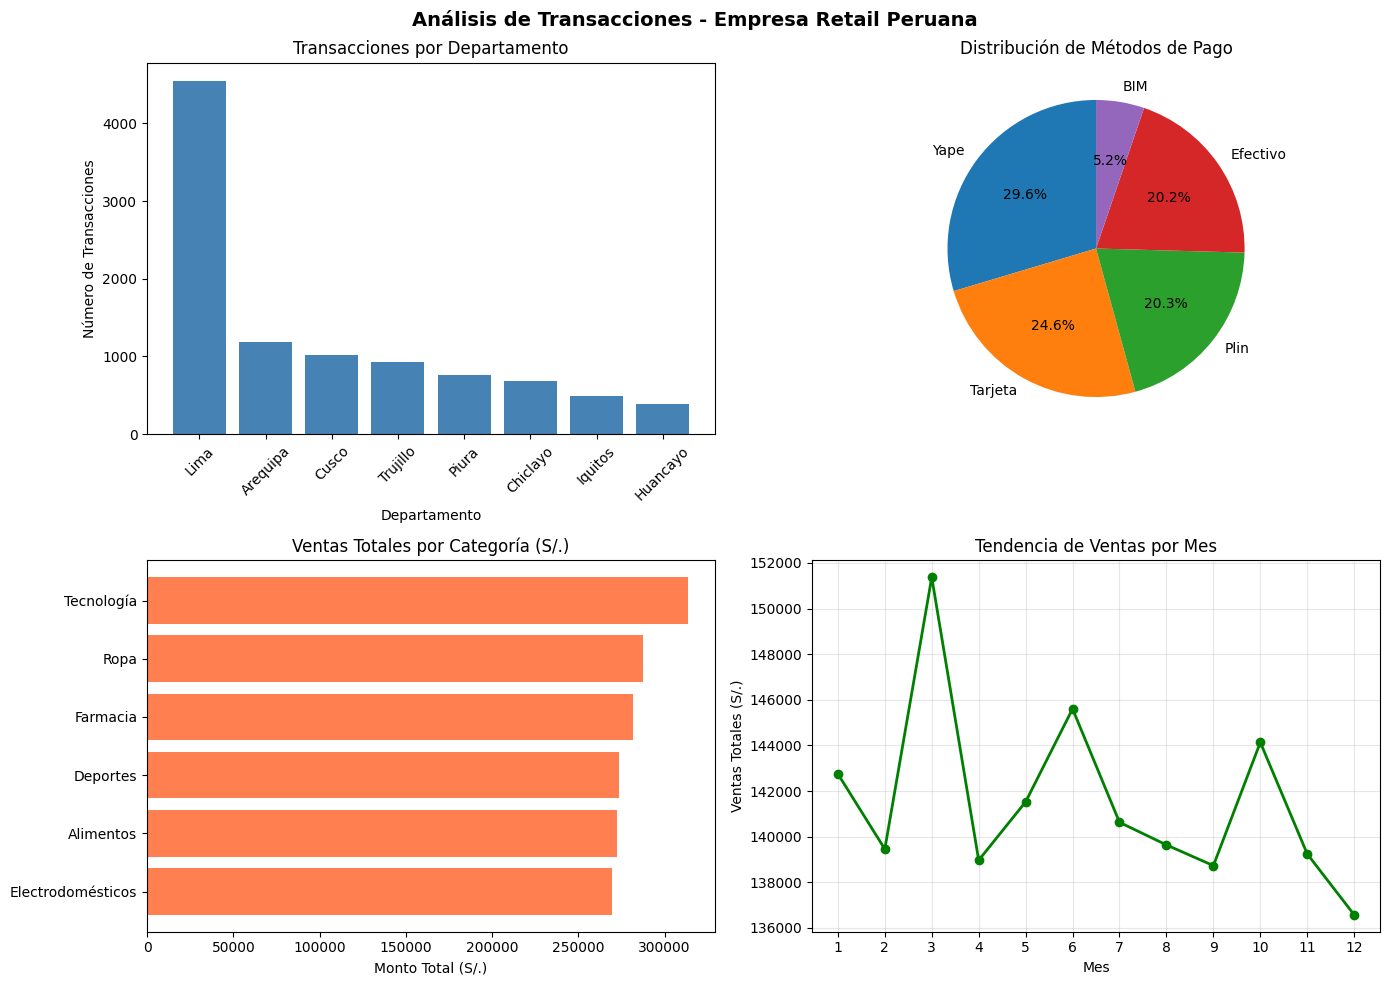

¡Gráfico guardado como 'analisis_transacciones.png'!


In [7]:
# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Transacciones - Empresa Retail Peruana', fontsize=14, fontweight='bold')

# Gráfico 1: Distribución por departamento
trans_x_dept = transacciones['departamento'].value_counts()
axes[0, 0].bar(trans_x_dept.index, trans_x_dept.values, color='steelblue')
axes[0, 0].set_title('Transacciones por Departamento')
axes[0, 0].set_xlabel('Departamento')
axes[0, 0].set_ylabel('Número de Transacciones')
axes[0, 0].tick_params(axis='x', rotation=45)

# Gráfico 2: Métodos de pago
metodo_pago = transacciones['metodo_pago'].value_counts()
axes[0, 1].pie(metodo_pago.values, labels=metodo_pago.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Distribución de Métodos de Pago')

# Gráfico 3: Ventas por categoría
ventas_categoria = transacciones.groupby('categoria')['monto_soles'].sum().sort_values(ascending=True)
axes[1, 0].barh(ventas_categoria.index, ventas_categoria.values, color='coral')
axes[1, 0].set_title('Ventas Totales por Categoría (S/.)')
axes[1, 0].set_xlabel('Monto Total (S/.)')

# Gráfico 4: Tendencia de ventas en el tiempo
ventas_mes = transacciones.groupby(transacciones['fecha'].dt.month)['monto_soles'].sum()
axes[1, 1].plot(ventas_mes.index, ventas_mes.values, marker='o', color='green', linewidth=2)
axes[1, 1].set_title('Tendencia de Ventas por Mes')
axes[1, 1].set_xlabel('Mes')
axes[1, 1].set_ylabel('Ventas Totales (S/.)')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_transacciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("¡Gráfico guardado como 'analisis_transacciones.png'!")

### PARTE 3: DATOS SEMI-ESTRUCTURADOS
### Paso 3.1: Trabajar con datos JSON (tipo API)

In [8]:
# Simular respuesta de una API (similar a la API de Reniec o SUNAT)
# Este es el tipo de dato semi-estructurado más común en sistemas modernos

datos_clientes_json = """
[
    {
        "id": "CLI-001",
        "nombres": "Juan Carlos",
        "apellidos": "Quispe Mamani",
        "dni": "45678901",
        "contacto": {
            "email": "jquispe@empresa.com",
            "telefono": "987654321",
            "distrito": "San Miguel"
        },
        "compras": [150.50, 320.00, 89.90],
        "fecha_registro": "2023-01-15",
        "activo": true,
        "etiquetas": ["premium", "fiel", "digital"]
    },
    {
        "id": "CLI-002", 
        "nombres": "Maria Elena",
        "apellidos": "Torres Flores",
        "dni": "56789012",
        "contacto": {
            "email": "matorres@gmail.com",
            "telefono": null,
            "distrito": "Miraflores"
        },
        "compras": [500.00, 1200.50],
        "fecha_registro": "2023-03-22",
        "activo": true,
        "etiquetas": ["vip", "presencial"]
    },
    {
        "id": "CLI-003",
        "nombres": "Roberto",
        "apellidos": "Mendoza García", 
        "dni": "67890123",
        "contacto": {
            "email": null,
            "telefono": "976543210",
            "distrito": "Callao"
        },
        "compras": [],
        "fecha_registro": "2024-01-05",
        "activo": false,
        "etiquetas": ["nuevo", "inactivo"]
    }
]
"""

# Parsear JSON
clientes = json.loads(datos_clientes_json)
print(f"Número de clientes: {len(clientes)}")
print(f"\nEstructura del primer cliente:")
print(json.dumps(clientes[0], indent=2, ensure_ascii=False))

Número de clientes: 3

Estructura del primer cliente:
{
  "id": "CLI-001",
  "nombres": "Juan Carlos",
  "apellidos": "Quispe Mamani",
  "dni": "45678901",
  "contacto": {
    "email": "jquispe@empresa.com",
    "telefono": "987654321",
    "distrito": "San Miguel"
  },
  "compras": [
    150.5,
    320.0,
    89.9
  ],
  "fecha_registro": "2023-01-15",
  "activo": true,
  "etiquetas": [
    "premium",
    "fiel",
    "digital"
  ]
}


### Paso 3.2: Análisis del JSON

In [9]:
# Convertir JSON a DataFrame para análisis
datos_tabulares = []
for cliente in clientes:
    datos_tabulares.append({
        'id': cliente['id'],
        'nombre_completo': f"{cliente['nombres']} {cliente['apellidos']}",
        'dni': cliente['dni'],
        'distrito': cliente['contacto']['distrito'],
        'tiene_email': cliente['contacto']['email'] is not None,
        'tiene_telefono': cliente['contacto']['telefono'] is not None,
        'total_compras': sum(cliente['compras']),
        'num_compras': len(cliente['compras']),
        'activo': cliente['activo'],
        'es_premium': 'premium' in cliente['etiquetas'] or 'vip' in cliente['etiquetas']
    })

df_clientes = pd.DataFrame(datos_tabulares)
print("=== CLIENTES CONVERTIDOS DE JSON A TABLA ===")
print(df_clientes.to_string(index=False))

print("\n=== RESUMEN DE COMPLETITUD DE DATOS ===")
print(f"Clientes con email: {df_clientes['tiene_email'].sum()}/{len(df_clientes)}")
print(f"Clientes con teléfono: {df_clientes['tiene_telefono'].sum()}/{len(df_clientes)}")
print(f"Clientes activos: {df_clientes['activo'].sum()}/{len(df_clientes)}")
print(f"Clientes premium/VIP: {df_clientes['es_premium'].sum()}/{len(df_clientes)}")

=== CLIENTES CONVERTIDOS DE JSON A TABLA ===
     id           nombre_completo      dni   distrito  tiene_email  tiene_telefono  total_compras  num_compras  activo  es_premium
CLI-001 Juan Carlos Quispe Mamani 45678901 San Miguel         True            True          560.4            3    True        True
CLI-002 Maria Elena Torres Flores 56789012 Miraflores         True           False         1700.5            2    True        True
CLI-003    Roberto Mendoza García 67890123     Callao        False            True            0.0            0   False       False

=== RESUMEN DE COMPLETITUD DE DATOS ===
Clientes con email: 2/3
Clientes con teléfono: 2/3
Clientes activos: 2/3
Clientes premium/VIP: 2/3


### PARTE 4: DATOS NO ESTRUCTURADOS

In [10]:
# Simular comentarios de clientes en redes sociales sobre una empresa peruana
comentarios_clientes = [
    "Excelente servicio en Plaza Vea de San Miguel, muy rápido el pago con Yape!",
    "Pésima atención, esperé 30 minutos para ser atendido, nunca más voy a Tottus de La Molina",
    "El producto llegó a tiempo pero la caja estaba dañada. Regular la experiencia",
    "Super bueno el envío express de Ripley, llegó en 2 horas a Miraflores",
    "Me cobraron de más y cuando reclamé me tardaron 1 semana en devolver el dinero",
    "El área de electrónica tiene todo, encontré el celular que buscaba a buen precio",
    "App del supermercado se cae constantemente, muy mala experiencia digital",
    "Calidad del producto excelente pero precio alto comparado con Metro",
    "Personal muy amable y capacitado para asesorar sobre productos",
    "Compré en línea y el producto era diferente a la foto, decepcionante"
]

print("=== ANÁLISIS DE DATOS NO ESTRUCTURADOS (TEXTO) ===")
print(f"Total de comentarios: {len(comentarios_clientes)}")

# Análisis básico sin librerías especializadas
palabras_positivas = ['excelente', 'super', 'bueno', 'rápido', 'amable', 'calidad']
palabras_negativas = ['pésima', 'mala', 'dañada', 'tardaron', 'decepcionante', 'se cae']

resultados = []
for i, comentario in enumerate(comentarios_clientes, 1):
    texto_lower = comentario.lower()
    score_pos = sum(1 for p in palabras_positivas if p in texto_lower)
    score_neg = sum(1 for p in palabras_negativas if p in texto_lower)
    
    if score_pos > score_neg:
        sentimiento = "POSITIVO"
    elif score_neg > score_pos:
        sentimiento = "NEGATIVO"
    else:
        sentimiento = "NEUTRO"
    
    num_palabras = len(comentario.split())
    resultados.append({
        'id': i,
        'sentimiento': sentimiento,
        'num_palabras': num_palabras,
        'comentario': comentario[:50] + "..."
    })
    
df_sentimientos = pd.DataFrame(resultados)
print("\n=== RESULTADOS DE ANÁLISIS DE SENTIMIENTO ===")
print(df_sentimientos.to_string(index=False))

print("\n=== RESUMEN ===")
print(df_sentimientos['sentimiento'].value_counts())

=== ANÁLISIS DE DATOS NO ESTRUCTURADOS (TEXTO) ===
Total de comentarios: 10

=== RESULTADOS DE ANÁLISIS DE SENTIMIENTO ===
 id sentimiento  num_palabras                                            comentario
  1    POSITIVO            14 Excelente servicio en Plaza Vea de San Miguel, muy...
  2    NEGATIVO            16 Pésima atención, esperé 30 minutos para ser atendi...
  3    NEGATIVO            13 El producto llegó a tiempo pero la caja estaba dañ...
  4    POSITIVO            13 Super bueno el envío express de Ripley, llegó en 2...
  5    NEGATIVO            15 Me cobraron de más y cuando reclamé me tardaron 1 ...
  6      NEUTRO            14 El área de electrónica tiene todo, encontré el cel...
  7    NEGATIVO            10 App del supermercado se cae constantemente, muy ma...
  8    POSITIVO            10 Calidad del producto excelente pero precio alto co...
  9    POSITIVO             9 Personal muy amable y capacitado para asesorar sob...
 10    NEGATIVO            12 Compré 

## 🏗️ PARTE 5: ARQUITECTURA BIG DATA — DISEÑO (20 minutos)

### Paso 5.1: Diseñar la arquitectura para tu empresa

A continuación, se presenta la propuesta de arquitectura Big Data adaptada a las necesidades operacionales, comerciales y de seguridad de una cadena de retail masivo en el Perú, cubriendo analítica en tiempo real, omnicanalidad y modelos predictivos.

In [13]:
import json

# ARQUITECTURA GENERAL DE BIG DATA PROPUESTA — PLAZA VEA (GRUPO 2)
arquitectura = {
    "empresa": "Supermercados Plaza Vea (SPSA - Intercorp)",
    "problema_principal": "Presencia de silos de información aislados entre canales físicos (cajas POS) y digitales (App/Web), lo que genera latencia crítica (más de 24 horas) para detectar transacciones fraudulentas con Tarjeta Oh!, demoras en la actualización del inventario omnicanal y pérdida de oportunidades de marketing en tiempo real.",
    
    "fuentes_de_datos": {
        "estructuradas": [
            "Base de datos transaccional central de puntos de venta POS (Oracle/SQL Server)", 
            "Historial crediticio y maestro de clientes de Financiera Oh!"
        ],
        "semi_estructuradas": [
            "Logs de navegación e interacciones en la App Delivery y tienda Web (Formatos JSON)", 
            "Webhooks y APIs de confirmación de pasarelas de pago digitales (Yape, Plin, Niubiz)"
        ],
        "no_estructuradas": [
            "Menciones, comentarios y reclamos extraídos de redes sociales (Facebook, X, Instagram)", 
            "Transcripciones de texto libre y llamadas del Call Center (Atención al Cliente)"
        ]
    },
    
    "estimacion_volumen": {
        "registros_por_dia": "Aproximadamente 1,200,000 transacciones y eventos diarios consolidando locales a nivel nacional.",
        "tamaño_estimado_por_año": "3.5 TB anuales (incluyendo datos estructurados de ventas, logs detallados de la aplicación móvil y almacenamiento intermedio de analítica de texto)."
    },
    
    "tecnologias_propuestas": {
        "ingesta": "Apache Kafka / AWS Kinesis (Para la captura y mensajería distribuida de streams de datos transaccionales en tiempo real).",
        "almacenamiento": "Databricks Delta Lake (Estructura Data Lakehouse montada sobre AWS S3 con almacenamiento desacoplado en capas Bronze, Silver y Gold).",
        "procesamiento": "PySpark (Spark Structured Streaming para canalizar los flujos en tiempo real y Spark MLlib para el entrenamiento escalable de modelos).",
        "visualizacion": "Power BI (Conexión DirectQuery a las tablas semánticas optimizadas en Delta Lake) para dashboards ejecutivos y Streamlit para prototipos rápidos de IA."
    },
    
    "casos_uso_principales": [
        "Módulo automatizado de prevención de fraudes: Evaluación probabilística de riesgo en transacciones con Tarjeta Oh! en menos de 2 segundos mediante modelos de Regresión Logística.",
        "Motor de recomendación hiper-personalizado: Envío de cupones de descuento automáticos mediante notificaciones Push a la App de Plaza Vea según la categoría preferida del cliente y su ubicación física actual.",
        "Monitoreo de reputación de marca y experiencia: Procesamiento de Lenguaje Natural (NLP) para clasificar el sentimiento de los comentarios en redes sociales y alertar de inmediato al equipo de tienda ante incidentes operativos graves."
    ]
}

print("=========================================================================")
print("🚀 PROCESANDO IMPRESIÓN DE ARQUITECTURA OFICIAL")
print("=========================================================================\n")
print(json.dumps(arquitectura, indent=2, ensure_ascii=False))

🚀 PROCESANDO IMPRESIÓN DE ARQUITECTURA OFICIAL

{
  "empresa": "Supermercados Plaza Vea (SPSA - Intercorp)",
  "problema_principal": "Presencia de silos de información aislados entre canales físicos (cajas POS) y digitales (App/Web), lo que genera latencia crítica (más de 24 horas) para detectar transacciones fraudulentas con Tarjeta Oh!, demoras en la actualización del inventario omnicanal y pérdida de oportunidades de marketing en tiempo real.",
  "fuentes_de_datos": {
    "estructuradas": [
      "Base de datos transaccional central de puntos de venta POS (Oracle/SQL Server)",
      "Historial crediticio y maestro de clientes de Financiera Oh!"
    ],
    "semi_estructuradas": [
      "Logs de navegación e interacciones en la App Delivery y tienda Web (Formatos JSON)",
      "Webhooks y APIs de confirmación de pasarelas de pago digitales (Yape, Plin, Niubiz)"
    ],
    "no_estructuradas": [
      "Menciones, comentarios y reclamos extraídos de redes sociales (Facebook, X, Instagram